# Classification

## Binary classification with Logistic Regression

In the following example, we'll use Logistic Regression (we'll go into detail about this algorithm in the next lecture) to classify breast tumors as malignant or benign based on the physical properties of the tumor (e.g. size, shape, texture).

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [ ]:

# Load the breast cancer dataset
bc_df, y = load_breast_cancer(return_X_y=True, as_frame=True)

# We'll uncomment the line below the second time through
# bc_df = bc_df[['worst texture']]

# The original dataset maps 0=malignant, 1=benign. This feels backwards to me, so I swap 0 and 1
y = 1-y 
display(bc_df.describe())
display(y.describe())

,worst texture
count,569.000000
mean,25.677223
std,6.146258
min,12.020000
25%,21.080000
50%,25.410000
75%,29.720000
max,49.540000


count    569.000000
mean       0.372583
std        0.483918
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64

First, we prepare the data.

Notice that the numerical values of the features range from numbers in the 1000s down to numbers less than 1. It will be important to scale the features.

In [23]:

X_train, X_test, y_train, y_test = train_test_split(bc_df, y, test_size= 0.2)

sc = StandardScaler()
Z_train = sc.fit_transform(X_train)
Z_test = sc.transform(X_test)

Now we create and fit the model.

In [24]:
logreg = LogisticRegression()
logreg.fit(Z_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
logreg.__dict__

{'penalty': 'l2',
 'dual': False,
 'tol': 0.0001,
 'C': 1.0,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'class_weight': None,
 'random_state': None,
 'solver': 'lbfgs',
 'max_iter': 100,
 'multi_class': 'deprecated',
 'verbose': 0,
 'warm_start': False,
 'n_jobs': None,
 'l1_ratio': None,
 'n_features_in_': 1,
 'classes_': array([0, 1]),
 'n_iter_': array([4], dtype=int32),
 'coef_': array([[1.09642569]]),
 'intercept_': array([-0.56505416])}

### Inspecting Feature Importance

Below, I rank the features based on their absolute value. BIG numbers (either positive or negative) correspond to important features, just like Linear Regression!

In [26]:
feature_names = list(bc_df.columns)

coefs = logreg.coef_.flatten()
coefs

idx = np.argsort(np.abs(coefs))

for i in idx[::-1]:
    print(f'{feature_names[i]:<30}\t{coefs[i]:+0.2f}')

worst texture                 	+1.10


In [27]:

y_pred_train = logreg.predict(Z_train)
y_pred_test = logreg.predict(Z_test)

y_prob_train = logreg.predict_proba(Z_train)
y_prob_test = logreg.predict_proba(Z_test)

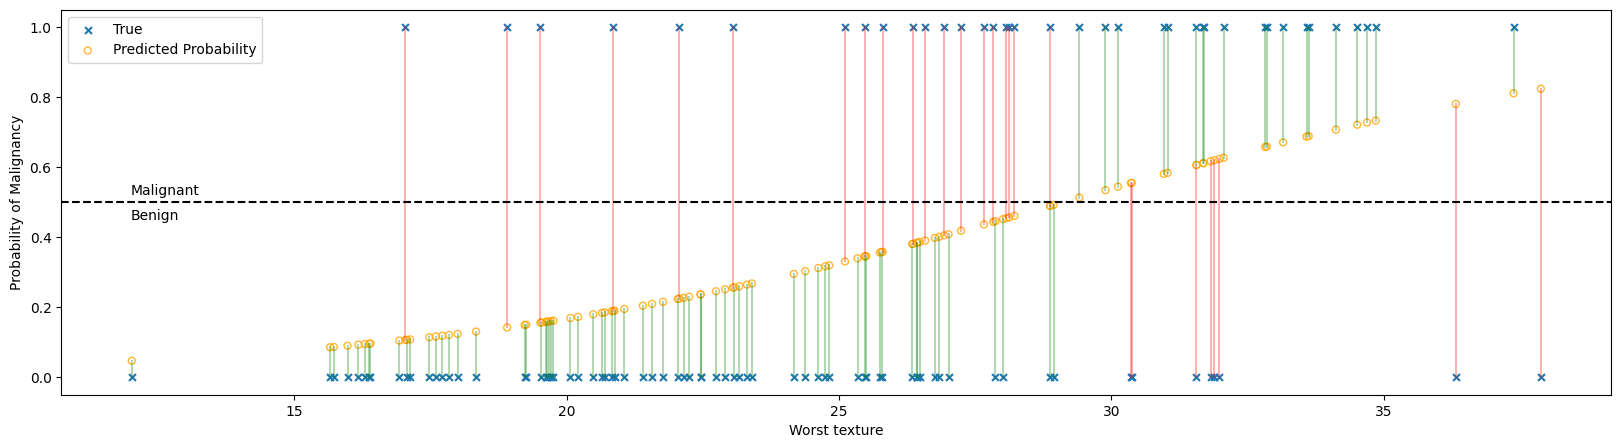

In [28]:

x = X_test['worst texture'].to_numpy().reshape(-1,1)

plt.subplots(1,1, figsize = (20, 5))

plt.scatter(x, y_test, label = 'True',
            s = 25, marker = 'x')

plt.scatter(x, y_prob_test[:,1], label = 'Predicted Probability', 
            s = 25, 
            alpha = 0.8, marker = 'o', ec = 'orange', facecolor = 'none')

idx_T = (y_test == y_pred_test)
plt.plot(np.column_stack((x[idx_T], x[idx_T])).T, np.column_stack((y_test[idx_T], y_prob_test[idx_T,1])).T, 'g-',
            alpha = 0.3, marker = 'none')

idx_F = (y_test != y_pred_test)
plt.plot(np.column_stack((x[idx_F], x[idx_F])).T, np.column_stack((y_test[idx_F], y_prob_test[idx_F,1])).T, 'r-',
            alpha = 0.3, marker = 'none')

plt.axhline(0.5, c = 'k', ls = '--')
plt.text(12, 0.52, 'Malignant')
plt.text(12, 0.45, 'Benign')

plt.legend()
plt.xlabel('Worst texture')
plt.ylabel('Probability of Malignancy')
plt.show()

In the figure above:
 - Each 'x' represents the true classification of a single tumor, benign at the bottom and malignant at the top. 
 - Each 'o' is the probability that the logistic regressor predicted given the feature set. A probability greater than 50% will be classified as malignant and less than 50% as benign.

The predictiction and true value are connected with a line to help show correspondences, with green lines being correct predictions and red lines showing incorrect predictions. Notice that all the red lines cross the 50% threshold line.

## Model Assessment

### Confusion Matrix

The *Confusion Matrix* is a graphical representation of the predictions a classifier has made on the data set. The confusion matrix is an nxn grid where n is the number of categories; for binary classification, the confusion matrix is always 2x2.

Let's look at the confusion matrix for the breast tumor classification above.

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, precision_recall_curve, PrecisionRecallDisplay


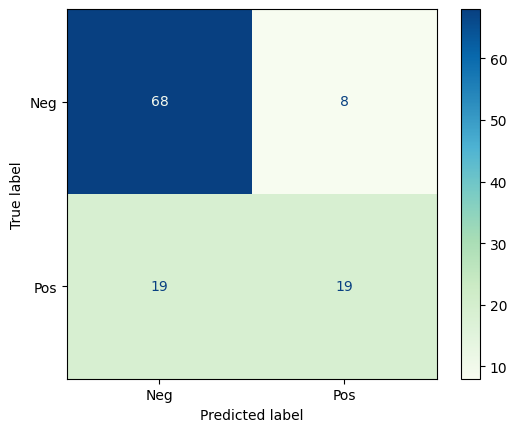

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, 
                                        # normalize = 'true',
                                        # display_labels = ['Benign', 'Malignant'],
                                        display_labels = ['Neg', 'Pos'],
                                        cmap = 'GnBu'
                                        )
plt.show()

In [31]:

cr = classification_report(y_test, y_pred_test, target_names = ['Benign', 'Malignant'])
print(cr)

              precision    recall  f1-score   support

      Benign       0.78      0.89      0.83        76
   Malignant       0.70      0.50      0.58        38

    accuracy                           0.76       114
   macro avg       0.74      0.70      0.71       114
weighted avg       0.76      0.76      0.75       114



/Users/eatai/.pyenv/versions/datascience/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


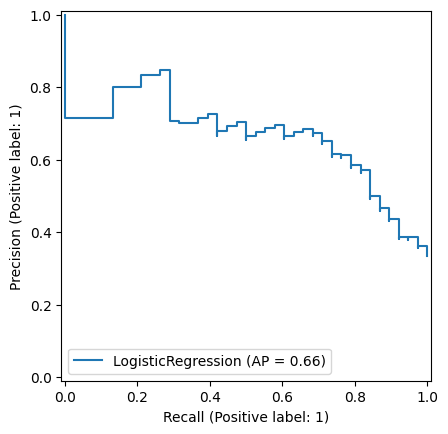

In [32]:
PrecisionRecallDisplay.from_estimator(logreg, X_test, y_test)
plt.show()